In [19]:
import numpy as np
import matplotlib.pyplot as plt

Activation functions

In [20]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def softplus(x):
    return np.log1p(np.exp(np.clip(x, -500, 500)))

def softplus_deriv(x):
    return sigmoid(x)   # d/dx softplus = sigmoid

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# Weight constraint reparameterization
def positive(W):
    return np.log1p(np.exp(np.clip(W, -500, 500)))

def positive_deriv(W):
    return sigmoid(W)

Datasets

In [21]:
#both equations were given in paper
def toy_function1(x, y, t, z):
    return (
        np.exp(-0.5 * x) + np.log1p(np.exp(0.4 * y))
        + np.tanh(t) + np.sin(z) - 0.4
    )

def toy_function2(x, y, t, z):
    fx = np.exp(-0.3 * x)
    fy = (0.15 * y)**2
    ft = np.tanh(0.3 * t)
    fz = 0.2 * np.sin(0.5 * z + 2) + 0.5
    return fx * fy * ft * fz

In [22]:
from scipy.stats import qmc

def generate_dataset(n_samples, low, high, func):
    sampler = qmc.LatinHypercube(d=4)
    sample = sampler.random(n=n_samples)
    scaled_samples = qmc.scale(sample, low, high)
    
    x = scaled_samples[:, 0:1]
    y = scaled_samples[:, 1:2]
    t = scaled_samples[:, 2:3]
    z = scaled_samples[:, 3:4]
    
    f = func(x, y, t, z)
    return x, y, t, z, f

Adam optimizer

In [23]:
def init_adam(params):
    m, v = {}, {}
    for k in params:
        m[k] = np.zeros_like(params[k])
        v[k] = np.zeros_like(params[k])
    return m, v

def adam_update(params, grads, m, v, t, lr=0.001, b1=0.9, b2=0.999, eps=1e-8):

    for k in params:
        g = grads["d"+k]

        m[k] = b1*m[k] + (1-b1)*g
        v[k] = b2*v[k] + (1-b2)*(g**2)

        m_hat = m[k]/(1-b1**t)
        v_hat = v[k]/(1-b2**t)

        params[k] -= lr * m_hat / (np.sqrt(v_hat)+eps)

    return params, m, v

ISNN1

In [24]:
def init_isnn1(hidden=10):
    return {
        "Wy": np.random.randn(1, hidden) * 0.1,
        "by": np.zeros((1, hidden)),
        "Wz": np.random.randn(1, hidden) * 0.1,
        "bz": np.zeros((1, hidden)),
        "Wt": np.random.randn(1, hidden) * 0.1,
        "bt": np.zeros((1, hidden)),
        "Wx1": np.random.randn(1 + 3*hidden, hidden) * 0.1,
        "bx1": np.zeros((1, hidden)),
        "Wx2": np.random.randn(hidden, 1) * 0.1,
        "bx2": np.zeros((1, 1)),
    }

def forward_isnn1(x, y, z, t, p):
    # Branch Activations
    Zy = y @ positive(p["Wy"]) + p["by"]
    Ay = softplus(Zy)

    Zz = z @ p["Wz"] + p["bz"]
    Az = sigmoid(Zz)

    Zt = t @ positive(p["Wt"]) + p["bt"]
    At = sigmoid(Zt)

    # Concatenate
    Xc = np.concatenate([x, Ay, Az, At], axis=1)

    # Fusion Layer
    Zx = Xc @ positive(p["Wx1"]) + p["bx1"]
    Ax = softplus(Zx)

    # Output Layer
    Zout = Ax @ p["Wx2"] + p["bx2"]

    cache = (x, y, z, t, Zy, Ay, Zz, Az, Zt, At, Xc, Zx, Ax)
    return Zout, cache

def backward_isnn1(Yhat, Y, p, cache):
    (x, y, z, t, Zy, Ay, Zz, Az, Zt, At, Xc, Zx, Ax) = cache
    m = Y.shape[0]
    grads = {}

    # Output Layer(No positivity constraint)
    dZout = (Yhat - Y) / m
    grads["dWx2"] = Ax.T @ dZout
    grads["dbx2"] = np.sum(dZout, axis=0, keepdims=True)

    # Fusion Layer(Wx1 is positive)
    dAx = dZout @ p["Wx2"].T
    dZx = dAx * softplus_deriv(Zx)

    # ADJUSTMENT: Apply positive_deriv to Wx1 gradient
    grads["dWx1"] = (Xc.T @ dZx) * positive_deriv(p["Wx1"])
    grads["dbx1"] = np.sum(dZx, axis=0, keepdims=True)

    # Backprop to Branches
    dXc = dZx @ positive(p["Wx1"]).T
    h = Ay.shape[1]

    # Split the concatenated gradient
    # index 0: x, 1 to h+1: Ay, h+1 to 2h+1: Az, 2h+1 to 3h+1: At
    dAy = dXc[:, 1 : 1 + h]
    dAz = dXc[:, 1 + h : 1 + 2 * h]
    dAt = dXc[:, 1 + 2 * h : 1 + 3 * h]

    # y-branch (Monotonic/Convex)
    dZy = dAy * softplus_deriv(Zy)
    grads["dWy"] = (y.T @ dZy) * positive_deriv(p["Wy"])
    grads["dby"] = np.sum(dZy, axis=0, keepdims=True)

    # z-branch (Arbitrary - No positive_deriv needed)
    dZz = dAz * sigmoid_deriv(Zz)
    grads["dWz"] = z.T @ dZz
    grads["dbz"] = np.sum(dZz, axis=0, keepdims=True)

    # t-branch (Monotonic)
    dZt = dAt * sigmoid_deriv(Zt)
    grads["dWt"] = (t.T @ dZt) * positive_deriv(p["Wt"])
    grads["dbt"] = np.sum(dZt, axis=0, keepdims=True)

    return grads

ISNN2

In [34]:
def init_isnn2(hidden=10):
    return {
        "Wy": np.random.randn(1, hidden) * 0.1,
        "by": np.zeros((1, hidden)),
        "Wz": np.random.randn(1, hidden) * 0.1,
        "bz": np.zeros((1, hidden)),
        "Wt": np.random.randn(1, hidden) * 0.1,
        "bt": np.zeros((1, hidden)),
        
        "Wx": np.random.randn(1, hidden) * 0.1, 
        
        "bx": np.zeros((1, hidden)),
        "Wx0": np.random.randn(1, hidden) * 0.1,
        
        "Wxy": np.random.randn(hidden, hidden) * 0.1,
        "Wxz": np.random.randn(hidden, hidden) * 0.1,
        "Wxt": np.random.randn(hidden, hidden) * 0.1,
        
        "Wout": np.random.randn(hidden, 1) * 0.1,
        "bout": np.zeros((1, 1)),
    }


def forward_isnn2(x0, y, z, t, p):
    # Branch Activations
    Zy = y @ positive(p["Wy"]) + p["by"]
    Ay = softplus(Zy)

    Zz = z @ p["Wz"] + p["bz"]
    Az = sigmoid(Zz)

    Zt = t @ positive(p["Wt"]) + p["bt"]
    At = sigmoid(Zt)

    # Interaction/Hidden state for x
    x_hidden = softplus(x0) 

    # Fusion Layer
    # Note: Wxy and Wxt MUST be positive to preserve branch properties
    Zx = (
        x_hidden @ positive(p["Wx"])
        + x0 @ p["Wx0"]
        + Ay @ positive(p["Wxy"]) # Adjusted for monotonicity
        + Az @ p["Wxz"]
        + At @ positive(p["Wxt"]) # Adjusted for monotonicity
        + p["bx"]
    )
    Ax = softplus(Zx)
    Zout = Ax @ p["Wout"] + p["bout"]

    cache = (x0, y, z, t, Zy, Ay, Zz, Az, Zt, At, x_hidden, Zx, Ax)
    return Zout, cache

def backward_isnn2(Yhat, Y, p, cache):
    (x0, y, z, t, Zy, Ay, Zz, Az, Zt, At, x_hidden, Zx, Ax) = cache
    m = Y.shape[0]
    grads = {}

    # Output Layer
    dZout = (Yhat - Y) / m
    grads["dWout"] = Ax.T @ dZout
    grads["dbout"] = np.sum(dZout, axis=0, keepdims=True)

    # Interaction Layer
    dAx = dZout @ p["Wout"].T
    dZx = dAx * softplus_deriv(Zx)

    # Chain rule for weights wrapped in positive
    grads["dWx"] = (x_hidden.T @ dZx) * positive_deriv(p["Wx"])
    grads["dbx"] = np.sum(dZx, axis=0, keepdims=True)
    grads["dWx0"] = x0.T @ dZx
    
    # Fusion gradients(with positivity derivative)
    grads["dWxy"] = (Ay.T @ dZx) * positive_deriv(p["Wxy"])
    grads["dWxz"] = Az.T @ dZx
    grads["dWxt"] = (At.T @ dZx) * positive_deriv(p["Wxt"])

    # Backprop into branches
    dAy = dZx @ positive(p["Wxy"]).T
    dAz = dZx @ p["Wxz"].T
    dAt = dZx @ positive(p["Wxt"]).T

    # y-branch (Monotonic/Convex)
    dZy = dAy * softplus_deriv(Zy)
    grads["dWy"] = (y.T @ dZy) * positive_deriv(p["Wy"])
    grads["dby"] = np.sum(dZy, axis=0, keepdims=True)

    # z-branch (Arbitrary)
    dZz = dAz * sigmoid_deriv(Zz)
    grads["dWz"] = z.T @ dZz
    grads["dbz"] = np.sum(dZz, axis=0, keepdims=True)

    # t-branch (Monotonic)
    dZt = dAt * sigmoid_deriv(Zt)
    grads["dWt"] = (t.T @ dZt) * positive_deriv(p["Wt"])
    grads["dbt"] = np.sum(dZt, axis=0, keepdims=True)

    return grads

FFNN

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)



def init_ffnn(input_dim=4, hidden=10):
    return {
        "W1": np.random.randn(input_dim, hidden) * 0.1,
        "b1": np.zeros((1, hidden)),
        "W2": np.random.randn(hidden, 1) * 0.1,
        "b2": np.zeros((1, 1))
    }

def forward_ffnn(x, y, z, t, p):
    # Combine all features into one vector (N, 4)
    X_full = np.concatenate([x, y, z, t], axis=1)
    
    Z1 = X_full @ p["W1"] + p["b1"]
    A1 = relu(Z1)
    
    Z2 = A1 @ p["W2"] + p["b2"] # Output layer
    
    cache = (X_full, Z1, A1, Z2)
    return Z2, cache

def backward_ffnn(Yhat, Y, p, cache):
    (X_full, Z1, A1, Z2) = cache
    m = Y.shape[0]
    grads = {}

    # Output Layer Gradient
    dZ2 = (Yhat - Y) / m
    grads["dW2"] = A1.T @ dZ2
    grads["db2"] = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden Layer Gradient
    dA1 = dZ2 @ p["W2"].T
    dZ1 = dA1 * relu_deriv(Z1)
    
    grads["dW1"] = X_full.T @ dZ1
    grads["db1"] = np.sum(dZ1, axis=0, keepdims=True)

    return grads

In [ ]:
def train_model(forward, backward, init_fn,
                x_train, y_train, z_train, t_train, Y_train,
                x_test, y_test, z_test, t_test, Y_test,
                epochs=1000, hidden=10, lr=0.001):

    # Initialize parameters and Adam state
    params = init_fn(hidden=hidden)
    m, v = init_adam(params)

    train_loss, test_loss = [], []

    for i in range(1, epochs + 1):
        # Forward Pass
        Yhat, cache = forward(x_train, y_train, z_train, t_train, params)
        loss = np.mean((Yhat - Y_train)**2)
        train_loss.append(loss)

        # Backward Pass 
        grads = backward(Yhat, Y_train, params, cache)
        
        # Adam Update
        params, m, v = adam_update(params, grads, m, v, i, lr=lr)

        # Forward Pass (Testing)
        Ytest, _ = forward(x_test, y_test, z_test, t_test, params)
        tl = np.mean((Ytest - Y_test)**2)
        test_loss.append(tl)

        # --- Logging ---
        if i % 100 == 0 or i == 1:
            print(f"Epoch {i:4d} | Train MSE: {loss:.6f} | Test MSE: {tl:.6f}")

    return params, train_loss, test_loss

Plotting

In [28]:
COLORS = {
    "FFNN": "red",
    "ISNN-1": "blue",
    "ISNN-2": "green"
}

In [29]:
def plot_loss_curves(results, log_every=1):
    plt.figure(figsize=(12, 4))
    titles = ["(a) Training Loss", "(b) Test Loss"]

    for idx, title in enumerate(titles):
        plt.subplot(1, 2, idx + 1)

        for name, data in results.items():
            losses = np.array([data[idx]])  # shape: (1, epochs)
            mean_loss = np.mean(losses, axis=0)
            std_loss  = np.std(losses, axis=0)

            epochs = (np.arange(len(mean_loss)) + 1) * log_every
            color = COLORS.get(name, None)

            plt.semilogy(epochs, mean_loss, label=name, color=color)
            plt.fill_between(
                epochs,
                mean_loss - std_loss,
                mean_loss + std_loss,
                alpha=0.2,
                color=color
            )

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.legend()
        plt.grid(True, which="both", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [30]:
def plot_behavior(models, true_fn, train_max=4.0, test_max=6.0, eq_name="Eq."):
    v_full = np.linspace(0, test_max, 500)
    v_train_mask = v_full <= train_max
    v_test_mask  = v_full > train_max

    plt.figure(figsize=(5 * len(models), 4))

    for i, (name, (forward_fn, params)) in enumerate(models.items()):
        plt.subplot(1, len(models), i + 1)

        # Convert to column vector for our NumPy forward passes
        vt = v_full.reshape(-1, 1)

        # True function (Now using pure NumPy)
        true_vals = true_fn(vt, vt, vt, vt).flatten()
        plt.plot(v_full, true_vals, 'k-', label="True", linewidth=1.5)

        # Model prediction using our custom forward function and learned params
        pred, _ = forward_fn(vt, vt, vt, vt, params)
        pred = pred.flatten()

        color = COLORS.get(name, "blue")

        # Interpolation
        plt.plot(
            v_full[v_train_mask], pred[v_train_mask],
            linestyle='--', color=color, label="Interpolated"
        )

        # Extrapolation
        plt.plot(
            v_full[v_test_mask], pred[v_test_mask],
            linestyle=':', color=color, label="Extrapolated"
        )

        # Train boundary
        plt.axvline(train_max, linestyle=':', color='gray')

        plt.title(f"{name} ({eq_name})")
        plt.xlabel("v (x=y=t=z)")
        plt.ylabel("f(v,v,v,v)")
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [31]:
def true_fn(x, y, z, t):
    """
    A synthetic function designed to test the ISNN constraints.
    - Monotonically increasing with respect to y and t.
    - Arbitrary with respect to x and z.
    """
    return 0.5 * x + np.power(y, 2) + np.sin(z) + np.exp(0.5 * t)

Main training loop

In [32]:
# tried with bboth 300000 and 3000
N_EPOCHS = 30000
# N_EPOCHS = 3000
learning_rate = 1e-3
np.random.seed(42)


--- Dataset 1 ---

Training FFNN...
Epoch    1 | Train MSE: 6.760211 | Test MSE: 6.499778
Epoch  100 | Train MSE: 1.517493 | Test MSE: 1.286400
Epoch  200 | Train MSE: 0.766220 | Test MSE: 2.510949
Epoch  300 | Train MSE: 0.665579 | Test MSE: 2.247367
Epoch  400 | Train MSE: 0.575998 | Test MSE: 2.005931
Epoch  500 | Train MSE: 0.505127 | Test MSE: 1.791288
Epoch  600 | Train MSE: 0.453030 | Test MSE: 1.611324
Epoch  700 | Train MSE: 0.413842 | Test MSE: 1.456732
Epoch  800 | Train MSE: 0.380477 | Test MSE: 1.313763
Epoch  900 | Train MSE: 0.348817 | Test MSE: 1.170428
Epoch 1000 | Train MSE: 0.317815 | Test MSE: 1.024765
Epoch 1100 | Train MSE: 0.287192 | Test MSE: 0.878569
Epoch 1200 | Train MSE: 0.257641 | Test MSE: 0.738835
Epoch 1300 | Train MSE: 0.229785 | Test MSE: 0.613383
Epoch 1400 | Train MSE: 0.203698 | Test MSE: 0.503241
Epoch 1500 | Train MSE: 0.178972 | Test MSE: 0.412834
Epoch 1600 | Train MSE: 0.154476 | Test MSE: 0.342097
Epoch 1700 | Train MSE: 0.130214 | Test MSE: 

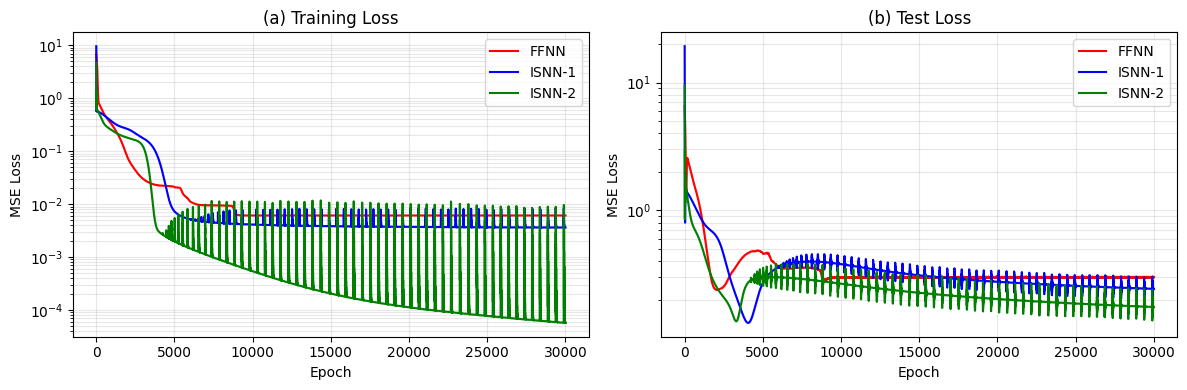

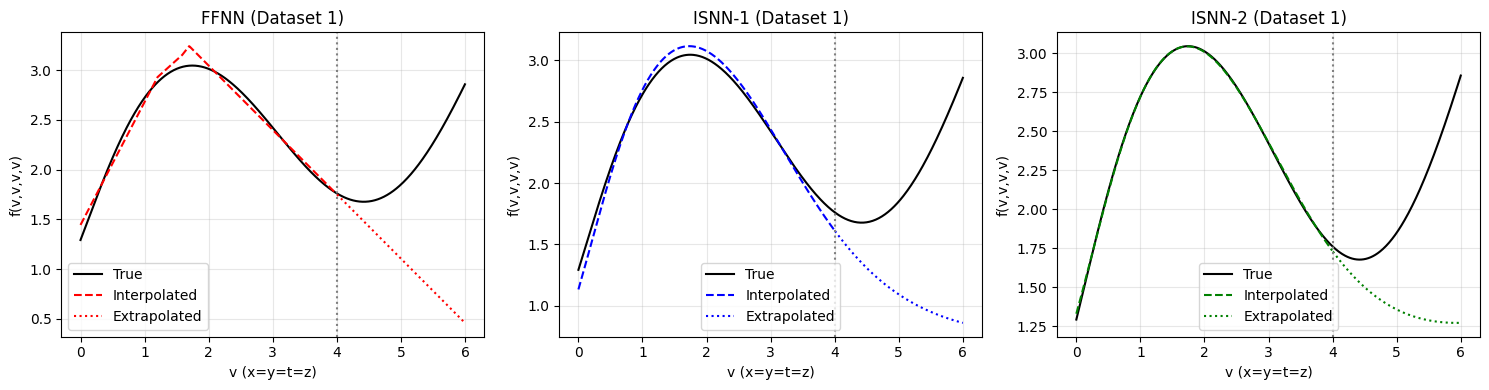


--- Dataset 2 ---

Training FFNN...
Epoch    1 | Train MSE: 0.002925 | Test MSE: 0.008052
Epoch  100 | Train MSE: 0.000102 | Test MSE: 0.000803
Epoch  200 | Train MSE: 0.000066 | Test MSE: 0.000622
Epoch  300 | Train MSE: 0.000041 | Test MSE: 0.000501
Epoch  400 | Train MSE: 0.000027 | Test MSE: 0.000411
Epoch  500 | Train MSE: 0.000021 | Test MSE: 0.000350
Epoch  600 | Train MSE: 0.000017 | Test MSE: 0.000323
Epoch  700 | Train MSE: 0.000015 | Test MSE: 0.000306
Epoch  800 | Train MSE: 0.000012 | Test MSE: 0.000293
Epoch  900 | Train MSE: 0.000011 | Test MSE: 0.000285
Epoch 1000 | Train MSE: 0.000010 | Test MSE: 0.000278
Epoch 1100 | Train MSE: 0.000009 | Test MSE: 0.000277
Epoch 1200 | Train MSE: 0.000008 | Test MSE: 0.000274
Epoch 1300 | Train MSE: 0.000008 | Test MSE: 0.000272
Epoch 1400 | Train MSE: 0.000008 | Test MSE: 0.000269
Epoch 1500 | Train MSE: 0.000007 | Test MSE: 0.000269
Epoch 1600 | Train MSE: 0.000007 | Test MSE: 0.000269
Epoch 1700 | Train MSE: 0.000007 | Test MSE: 

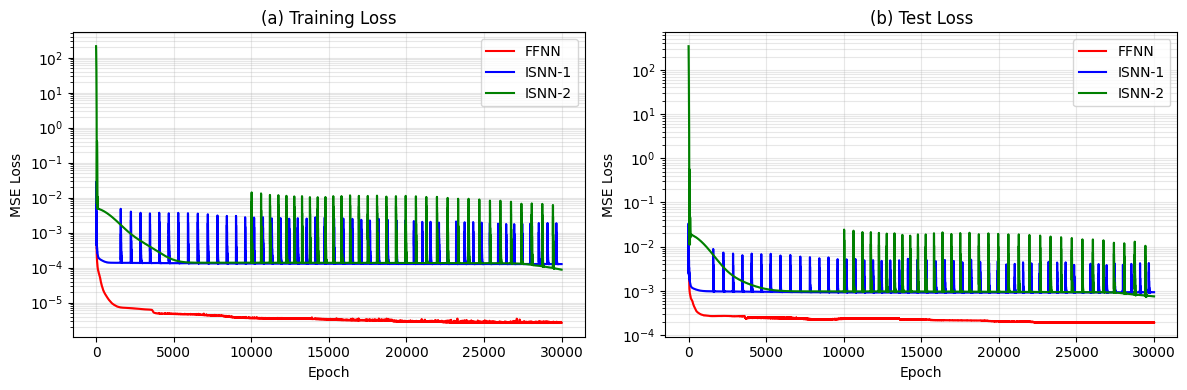

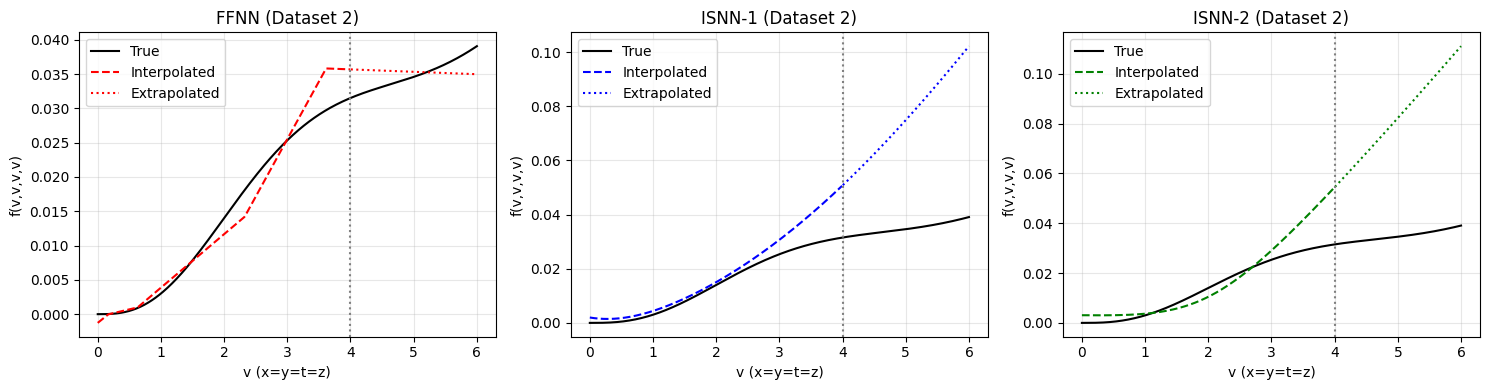

In [35]:
datasets = [
("Dataset 1", toy_function1),
("Dataset 2", toy_function2)
]

for name, func in datasets:
    print(f"\n{'='*40}")
    print(f"--- {name} ---")
    print(f"{'='*40}")

    # Generate Data
    x_tr, y_tr, z_tr, t_tr, f_tr = generate_dataset(500, 0, 4, func)
    x_te, y_te, z_te, t_te, f_te = generate_dataset(5000, 0, 6, func)

    results = {}
    models_for_plot = {}

    # Train Models
    # FFNN
    print("\nTraining FFNN...")
    init_ffnn_wrapper = lambda hidden: init_ffnn(input_dim=4, hidden=hidden)
    
    params_ffnn, train_lf, test_lf = train_model(
        forward_ffnn, backward_ffnn, init_ffnn_wrapper,
        x_tr, y_tr, z_tr, t_tr, f_tr,
        x_te, y_te, z_te, t_te, f_te,
        epochs=N_EPOCHS, hidden=10, lr=learning_rate
    )

    results["FFNN"] = (train_lf, test_lf)
    models_for_plot["FFNN"] = (forward_ffnn, params_ffnn)



    # ISNN-1
    print("\nTraining ISNN-1...")
    params_isnn1, train_l1, test_l1 = train_model(
        forward_isnn1, backward_isnn1, init_isnn1,
        x_tr, y_tr, z_tr, t_tr, f_tr,
        x_te, y_te, z_te, t_te, f_te,
        epochs=N_EPOCHS, hidden=10, lr=learning_rate
    )

    results["ISNN-1"] = (train_l1, test_l1)
    models_for_plot["ISNN-1"] = (forward_isnn1, params_isnn1)


    # ISNN-2
    print("\nTraining ISNN-2...")
    params_isnn2, train_l2, test_l2 = train_model(
        forward_isnn2, backward_isnn2, init_isnn2,
        x_tr, y_tr, z_tr, t_tr, f_tr,
        x_te, y_te, z_te, t_te, f_te,
        epochs=N_EPOCHS, hidden=15, lr=learning_rate
    )

    results["ISNN-2"] = (train_l2, test_l2)
    models_for_plot["ISNN-2"] = (forward_isnn2, params_isnn2)


    # Plotting
    print(f"\nPlotting Results for {name}...")
    
    # Loss Curves
    plot_loss_curves(results, log_every=1)

    # Behavior Curves
    plot_behavior(
        models_for_plot,
        lambda v1, v2, v3, v4: func(v1, v2, v3, v4),
        train_max=4.0, test_max=6.0, eq_name=name
    )

with 3000 epochs


--- Dataset 1 ---

Training FFNN...
Epoch    1 | Train MSE: 6.487904 | Test MSE: 6.120689
Epoch  100 | Train MSE: 3.109270 | Test MSE: 2.217516
Epoch  200 | Train MSE: 0.803413 | Test MSE: 2.571785
Epoch  300 | Train MSE: 0.692354 | Test MSE: 2.365632
Epoch  400 | Train MSE: 0.588286 | Test MSE: 2.110374
Epoch  500 | Train MSE: 0.481477 | Test MSE: 1.778018
Epoch  600 | Train MSE: 0.414348 | Test MSE: 1.559739
Epoch  700 | Train MSE: 0.367931 | Test MSE: 1.334388
Epoch  800 | Train MSE: 0.327358 | Test MSE: 1.131286
Epoch  900 | Train MSE: 0.288980 | Test MSE: 0.929415
Epoch 1000 | Train MSE: 0.256203 | Test MSE: 0.759397
Epoch 1100 | Train MSE: 0.231233 | Test MSE: 0.625275
Epoch 1200 | Train MSE: 0.215713 | Test MSE: 0.510189
Epoch 1300 | Train MSE: 0.206794 | Test MSE: 0.435889
Epoch 1400 | Train MSE: 0.199298 | Test MSE: 0.385089
Epoch 1500 | Train MSE: 0.138783 | Test MSE: 0.331149
Epoch 1600 | Train MSE: 0.094138 | Test MSE: 0.263273
Epoch 1700 | Train MSE: 0.065617 | Test MSE: 

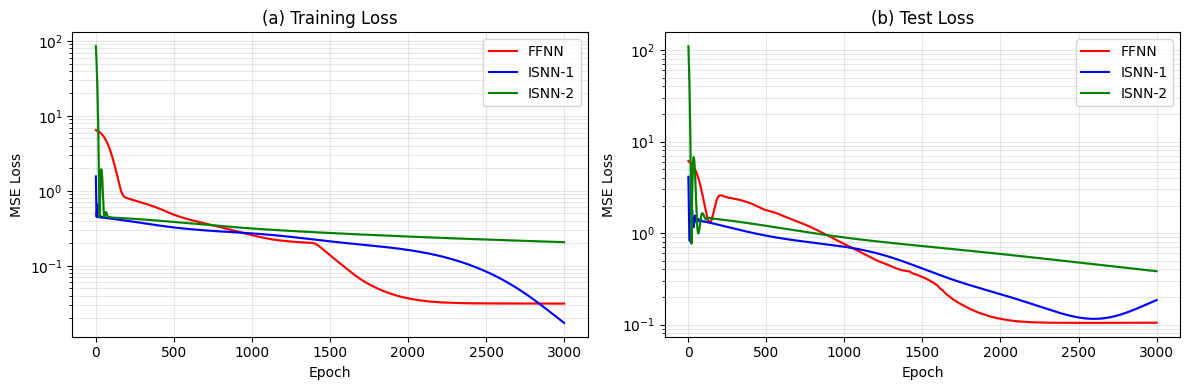

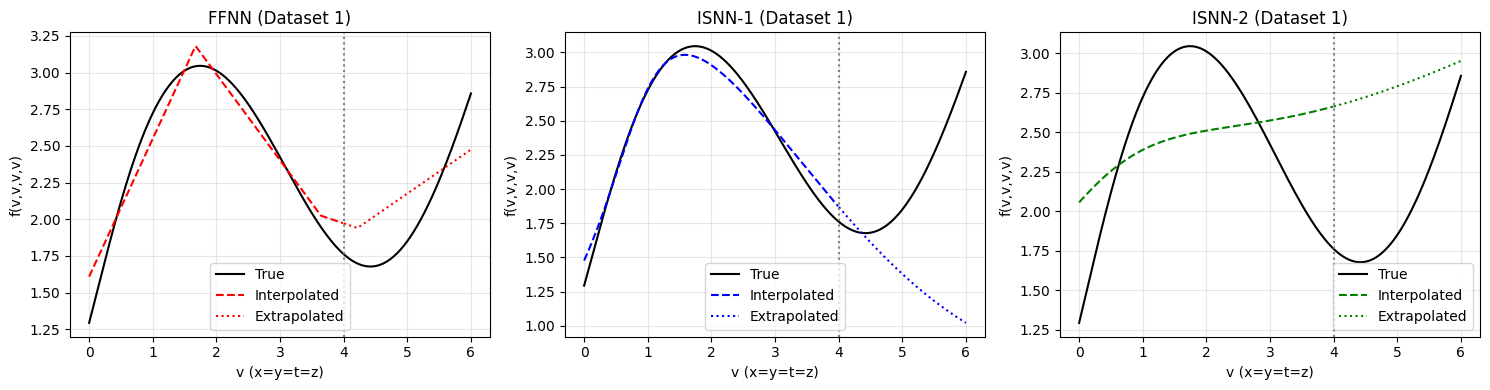


--- Dataset 2 ---

Training FFNN...
Epoch    1 | Train MSE: 0.005641 | Test MSE: 0.013406
Epoch  100 | Train MSE: 0.000197 | Test MSE: 0.001533
Epoch  200 | Train MSE: 0.000111 | Test MSE: 0.001053
Epoch  300 | Train MSE: 0.000067 | Test MSE: 0.000771
Epoch  400 | Train MSE: 0.000051 | Test MSE: 0.000636
Epoch  500 | Train MSE: 0.000042 | Test MSE: 0.000563
Epoch  600 | Train MSE: 0.000035 | Test MSE: 0.000512
Epoch  700 | Train MSE: 0.000031 | Test MSE: 0.000475
Epoch  800 | Train MSE: 0.000027 | Test MSE: 0.000441
Epoch  900 | Train MSE: 0.000023 | Test MSE: 0.000411
Epoch 1000 | Train MSE: 0.000020 | Test MSE: 0.000386
Epoch 1100 | Train MSE: 0.000018 | Test MSE: 0.000362
Epoch 1200 | Train MSE: 0.000016 | Test MSE: 0.000343
Epoch 1300 | Train MSE: 0.000014 | Test MSE: 0.000329
Epoch 1400 | Train MSE: 0.000013 | Test MSE: 0.000306
Epoch 1500 | Train MSE: 0.000011 | Test MSE: 0.000288
Epoch 1600 | Train MSE: 0.000010 | Test MSE: 0.000272
Epoch 1700 | Train MSE: 0.000009 | Test MSE: 

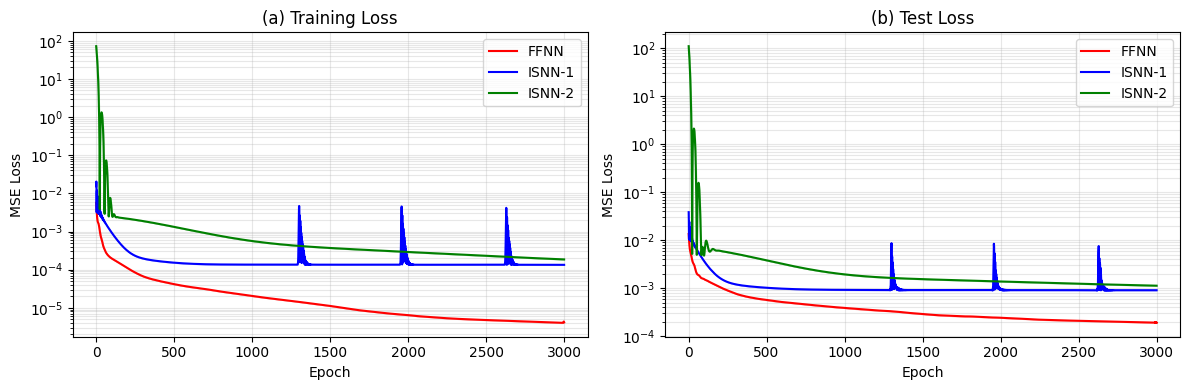

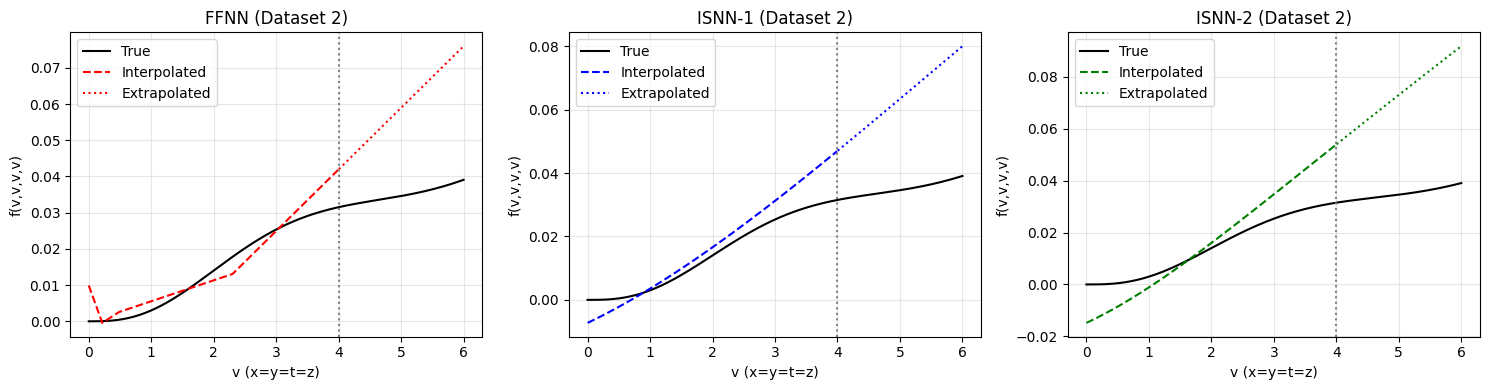

In [36]:
# tried with bboth 300000 and 3000
# N_EPOCHS = 30000
N_EPOCHS = 3000
learning_rate = 1e-3
np.random.seed(42)

datasets = [
("Dataset 1", toy_function1),
("Dataset 2", toy_function2)
]

for name, func in datasets:
    print(f"\n{'='*40}")
    print(f"--- {name} ---")
    print(f"{'='*40}")

    # Generate Data
    x_tr, y_tr, z_tr, t_tr, f_tr = generate_dataset(500, 0, 4, func)
    x_te, y_te, z_te, t_te, f_te = generate_dataset(5000, 0, 6, func)

    results = {}
    models_for_plot = {}

    # Train Models
    # FFNN
    print("\nTraining FFNN...")
    init_ffnn_wrapper = lambda hidden: init_ffnn(input_dim=4, hidden=hidden)
    
    params_ffnn, train_lf, test_lf = train_model(
        forward_ffnn, backward_ffnn, init_ffnn_wrapper,
        x_tr, y_tr, z_tr, t_tr, f_tr,
        x_te, y_te, z_te, t_te, f_te,
        epochs=N_EPOCHS, hidden=10, lr=learning_rate
    )

    results["FFNN"] = (train_lf, test_lf)
    models_for_plot["FFNN"] = (forward_ffnn, params_ffnn)



    # ISNN-1
    print("\nTraining ISNN-1...")
    params_isnn1, train_l1, test_l1 = train_model(
        forward_isnn1, backward_isnn1, init_isnn1,
        x_tr, y_tr, z_tr, t_tr, f_tr,
        x_te, y_te, z_te, t_te, f_te,
        epochs=N_EPOCHS, hidden=10, lr=learning_rate
    )

    results["ISNN-1"] = (train_l1, test_l1)
    models_for_plot["ISNN-1"] = (forward_isnn1, params_isnn1)


    # ISNN-2
    print("\nTraining ISNN-2...")
    params_isnn2, train_l2, test_l2 = train_model(
        forward_isnn2, backward_isnn2, init_isnn2,
        x_tr, y_tr, z_tr, t_tr, f_tr,
        x_te, y_te, z_te, t_te, f_te,
        epochs=N_EPOCHS, hidden=15, lr=learning_rate
    )

    results["ISNN-2"] = (train_l2, test_l2)
    models_for_plot["ISNN-2"] = (forward_isnn2, params_isnn2)


    # Plotting
    print(f"\nPlotting Results for {name}...")
    
    # Loss Curves
    plot_loss_curves(results, log_every=1)

    # Behavior Curves
    plot_behavior(
        models_for_plot,
        lambda v1, v2, v3, v4: func(v1, v2, v3, v4),
        train_max=4.0, test_max=6.0, eq_name=name
    )